# Black Friday Sales Data Analysis

**Problem Statement:**  
The objective of this project is to analyze 537,000+ Black Friday sales transactions to **identify customer purchasing behavior, product preferences, and spending patterns,** helping retailers make data-driven decisions for marketing, inventory management, and customer segmentation.

**Dataset:** 537,577 rows × 12 columns
**Tools:** Python, Pandas, Matplotlib, Seaborn

## 1. Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

In [6]:
df = pd.read_csv('BlackFriday.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (537577, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [30]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.375770e+05,537577.00000,537577.000000,537577.000000,370591.000000,164278.000000,537577.000000
mean,1.002992e+06,8.08271,0.408797,5.295546,9.842144,12.669840,9333.859853
std,1.714393e+03,6.52412,0.491612,3.750701,5.087259,4.124341,4981.022133
min,1.000001e+06,0.00000,0.000000,1.000000,2.000000,3.000000,185.000000
25%,1.001495e+06,2.00000,0.000000,1.000000,5.000000,9.000000,5866.000000
50%,1.003031e+06,7.00000,0.000000,5.000000,9.000000,14.000000,8062.000000
75%,1.004417e+06,14.00000,1.000000,8.000000,15.000000,16.000000,12073.000000
max,1.006040e+06,20.00000,1.000000,18.000000,18.000000,18.000000,23961.000000


In [4]:
# Missing values check
print('Missing Values:')
print(df.isnull().sum())
print()
print('Missing % :')
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing Values:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

Missing % :
User_ID                        0.00
Product_ID                     0.00
Gender                         0.00
Age                            0.00
Occupation                     0.00
City_Category                  0.00
Stay_In_Current_City_Years     0.00
Marital_Status                 0.00
Product_Category_1             0.00
Product_Category_2            31.06
Product_Category_3            69.44
Purchase                       0.00
dtype: float64


## 4. Data Cleaning

In [7]:
# Product_Category_2 and _3 have large amount of null values — Lets drop them
df_clean = df.drop(columns=['Product_Category_2', 'Product_Category_3'])

# Making Marital_Status readable
df_clean['Marital_Status'] = df_clean['Marital_Status'].map({0: 'Single', 1: 'Married'})

# Gender full name
df_clean['Gender'] = df_clean['Gender'].map({'M': 'Male', 'F': 'Female'})

print('Cleaned dataset shape:', df_clean.shape)
df_clean.head()

Cleaned dataset shape: (537577, 10)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,Female,0-17,10,A,2,Single,3,8370
1,1000001,P00248942,Female,0-17,10,A,2,Single,1,15200
2,1000001,P00087842,Female,0-17,10,A,2,Single,12,1422
3,1000001,P00085442,Female,0-17,10,A,2,Single,12,1057
4,1000002,P00285442,Male,55+,16,C,4+,Single,8,7969


---
## 5. Analysis — Dashboard 1: Customer Profile

### 5.1 Gender Distribution

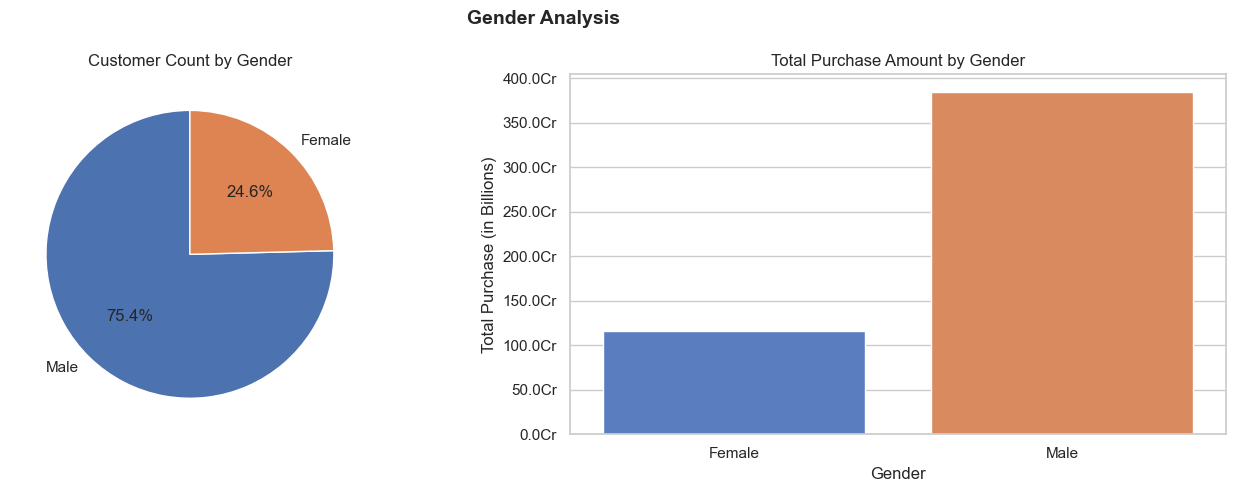

Insight: Male customers account for ~75% of purchases — retailers should focus male-targeted marketing on Black Friday.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of customers by gender
gender_count = df_clean['Gender'].value_counts()
axes[0].pie(gender_count, labels=gender_count.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Customer Count by Gender')

# Total purchase by gender
gender_purchase = df_clean.groupby('Gender')['Purchase'].sum().reset_index()
sns.barplot(data=gender_purchase, x='Gender', y='Purchase', ax=axes[1], palette='muted')
axes[1].set_title('Total Purchase Amount by Gender')
axes[1].set_ylabel('Total Purchase (in Billions)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}Cr'))

plt.suptitle('Gender Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Male customers account for ~75% of purchases — retailers should focus male-targeted marketing on Black Friday.')

### 5.2 Age Group Analysis

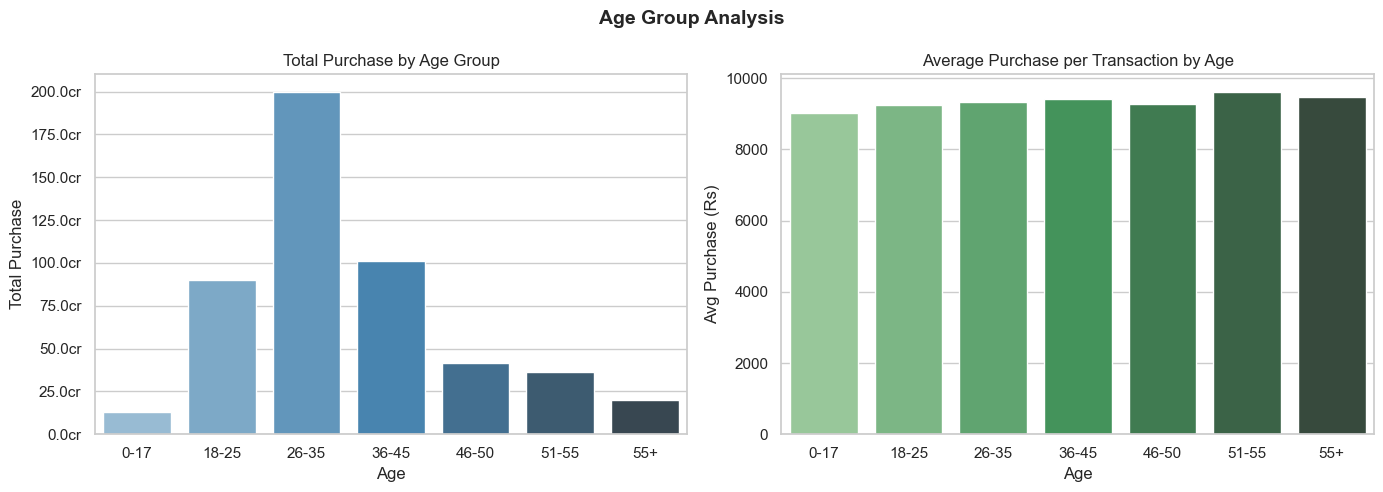

Insight: Age group 26-35 contributes the highest total revenue — primary target audience for Black Friday campaigns.


In [22]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total purchase by age
age_purchase = df_clean.groupby('Age')['Purchase'].sum().reindex(age_order).reset_index()
sns.barplot(data=age_purchase, x='Age', y='Purchase', ax=axes[0],
            order=age_order, palette='Blues_d')
axes[0].set_title('Total Purchase by Age Group')
axes[0].set_ylabel('Total Purchase')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}cr'))

# Average purchase by age
age_avg = df_clean.groupby('Age')['Purchase'].mean().reindex(age_order).reset_index()
sns.barplot(data=age_avg, x='Age', y='Purchase', ax=axes[1],
            order=age_order, palette='Greens_d')
axes[1].set_title('Average Purchase per Transaction by Age')
axes[1].set_ylabel('Avg Purchase (Rs)')

plt.suptitle('Age Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Age group 26-35 contributes the highest total revenue — primary target audience for Black Friday campaigns.')

### 5.3 Marital Status Analysis

In [47]:
marital_count = df_clean[['Gender','Marital_Status']].value_counts()
print(marital_count)
df_clean.groupby(['Gender','Marital_Status'])['User_ID'].count()

Gender  Marital_Status
Male    Single            240843
        Married           164537
Female  Single             76974
        Married            55223
Name: count, dtype: int64


Gender  Marital_Status
Female  Married            55223
        Single             76974
Male    Married           164537
        Single            240843
Name: User_ID, dtype: int64

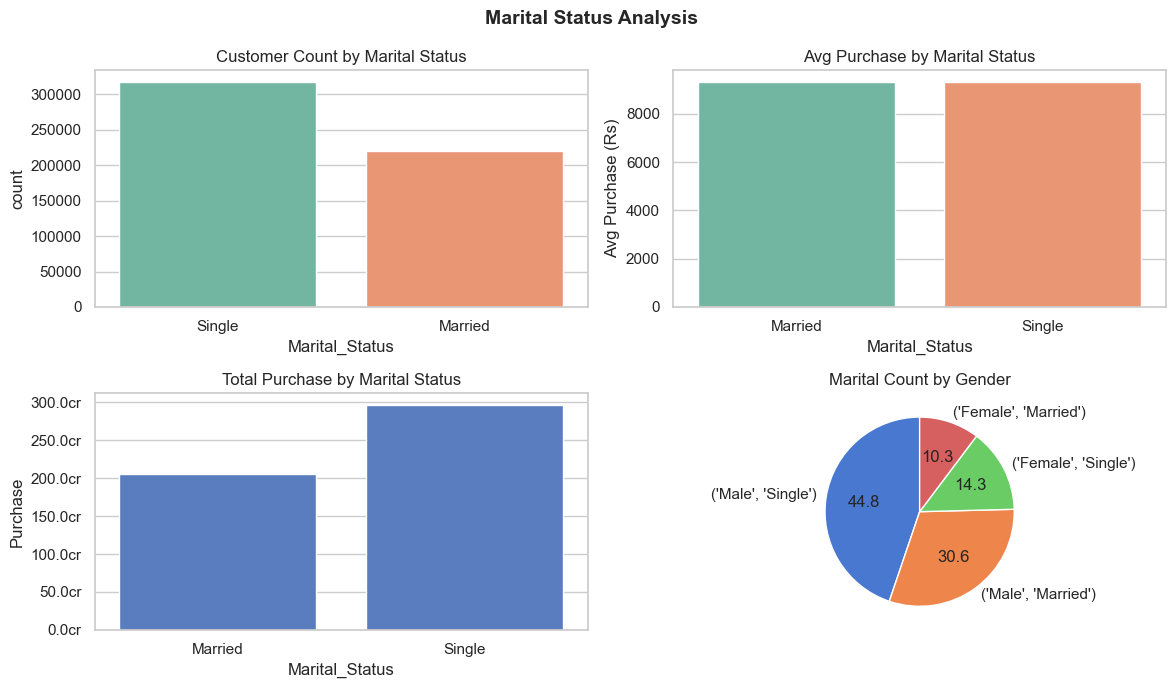

Insight: Single customers spend slightly more per transaction than married ones however male dominates in both categories.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Count
sns.countplot(data=df_clean, x='Marital_Status', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Customer Count by Marital Status')

# Average purchase
marital_avg = df_clean.groupby('Marital_Status')['Purchase'].mean().reset_index()
sns.barplot(data=marital_avg, x='Marital_Status', y='Purchase', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Avg Purchase by Marital Status')
axes[0,1].set_ylabel('Avg Purchase (Rs)')

# Total Purchase by marital status
marital_sum = df_clean.groupby("Marital_Status")['Purchase'].sum().reset_index()
sns.barplot(x='Marital_Status',y='Purchase',data=marital_sum,ax=axes[1,0])
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}cr'))
axes[1,0].set_title('Total Purchase by Marital Status')

#Gender and Marital Status
marital_count = df_clean[['Gender','Marital_Status']].value_counts()
axes[1,1].pie(marital_count,labels=marital_count.index,autopct='%.1f',startangle=90)
axes[1,1].set_title('Marital Count by Gender')

plt.suptitle('Marital Status Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('marital_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Single customers spend slightly more per transaction than married ones however male dominates in both categories.')

### 5.4 Gender + Marital Status Combined

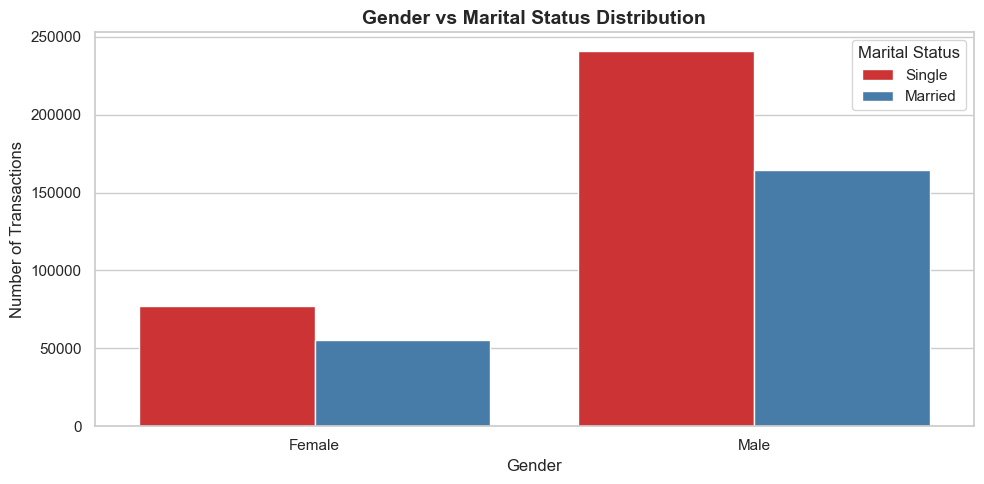

Insight: Single Males are the largest customer segment — most valuable group for targeted offers.


In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Gender', hue='Marital_Status', palette='Set1')
plt.title('Gender vs Marital Status Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.legend(title='Marital Status')
plt.tight_layout()
plt.savefig('gender_marital.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Single Males are the largest customer segment — most valuable group for targeted offers.')

---
## 6. Analysis — Dashboard 2: City & Location

### 6.1 City Category Analysis

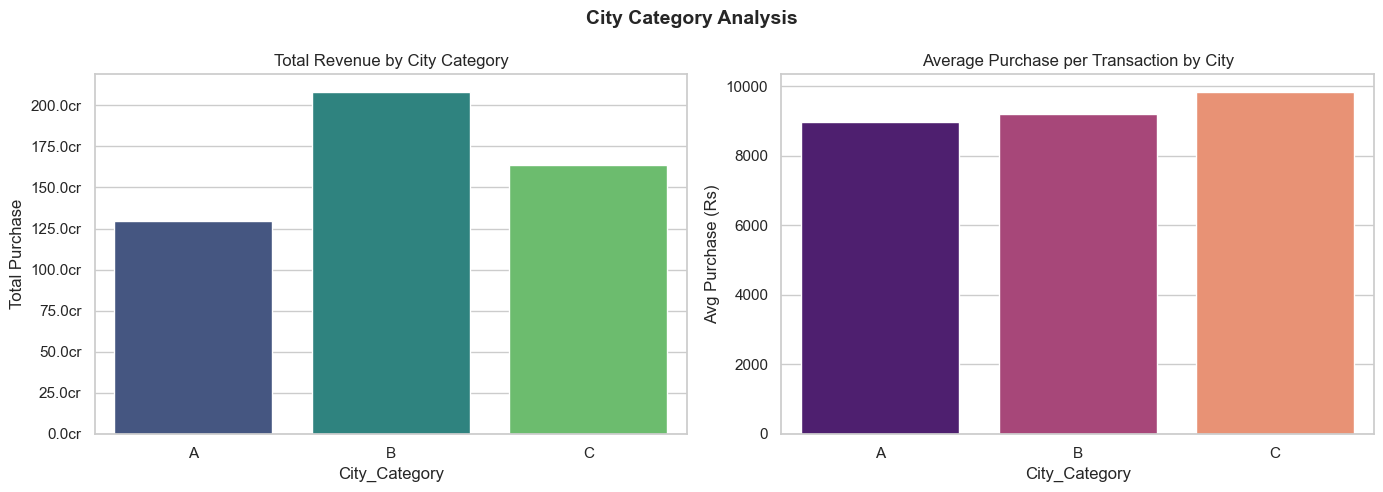

Insight: City B generates highest total revenue — priority market for Black Friday deals.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total purchase by city
city_purchase = df_clean.groupby('City_Category')['Purchase'].sum().reset_index()
sns.barplot(data=city_purchase, x='City_Category', y='Purchase', ax=axes[0], palette='viridis')
axes[0].set_title('Total Revenue by City Category')
axes[0].set_ylabel('Total Purchase')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}cr'))

# Avg purchase by city
city_avg = df_clean.groupby('City_Category')['Purchase'].mean().reset_index()
sns.barplot(data=city_avg, x='City_Category', y='Purchase', ax=axes[1], palette='magma')
axes[1].set_title('Average Purchase per Transaction by City')
axes[1].set_ylabel('Avg Purchase (Rs)')

plt.suptitle('City Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('city_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: City B generates highest total revenue — priority market for Black Friday deals.')

### 6.2 Stay in Current City Years

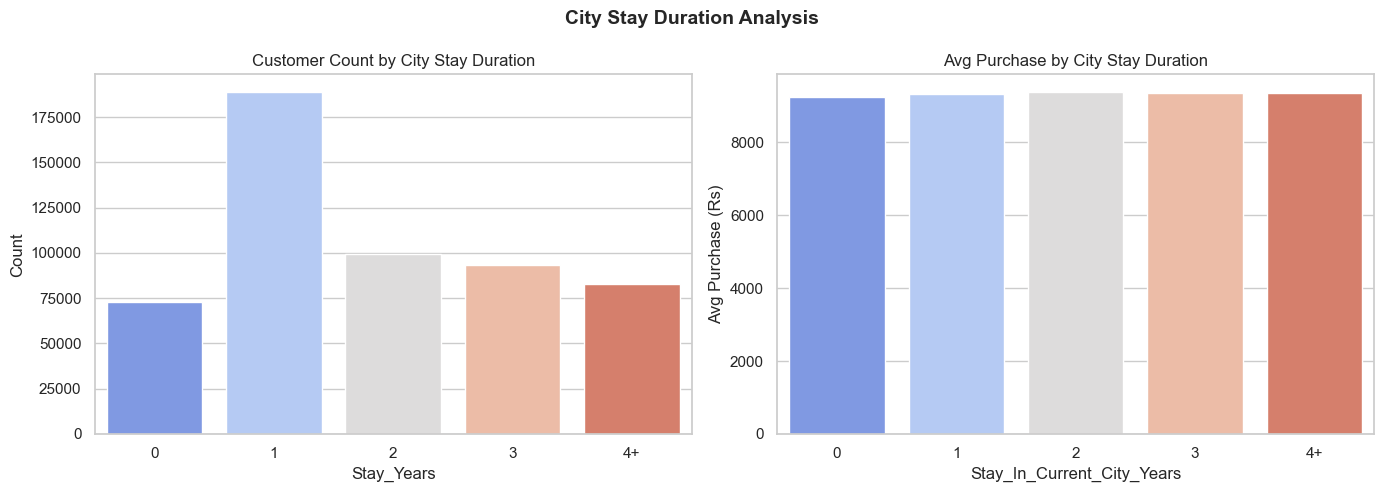

Insight: Customers who stayed 1 year in city are highest in count — likely new residents exploring shopping options.


In [11]:
stay_order = ['0', '1', '2', '3', '4+']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stay_count = df_clean['Stay_In_Current_City_Years'].value_counts().reindex(stay_order).reset_index()
stay_count.columns = ['Stay_Years', 'Count']
sns.barplot(data=stay_count, x='Stay_Years', y='Count', ax=axes[0], palette='coolwarm')
axes[0].set_title('Customer Count by City Stay Duration')

stay_purchase = df_clean.groupby('Stay_In_Current_City_Years')['Purchase'].mean().reindex(stay_order).reset_index()
sns.barplot(data=stay_purchase, x='Stay_In_Current_City_Years', y='Purchase', ax=axes[1], palette='coolwarm')
axes[1].set_title('Avg Purchase by City Stay Duration')
axes[1].set_ylabel('Avg Purchase (Rs)')

plt.suptitle('City Stay Duration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stay_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Customers who stayed 1 year in city are highest in count — likely new residents exploring shopping options.')

---
## 7. Analysis — Dashboard 3: Product Analysis

### 7.1 Top Product Categories

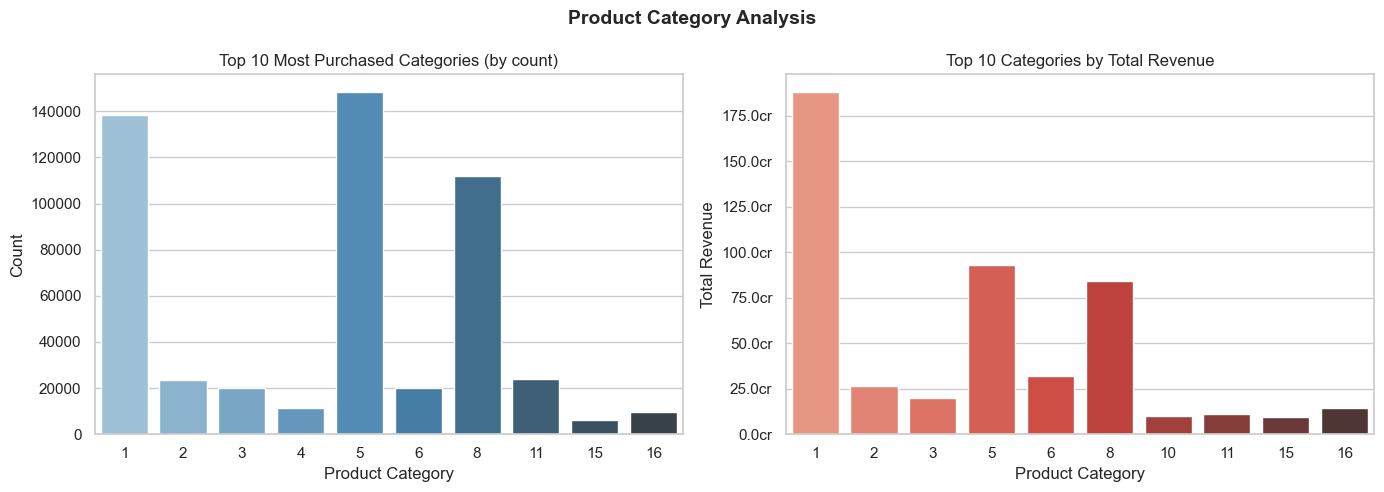

Insight: Category 1 and 5 dominate both transaction count and revenue — top priority for restocking.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of transactions per category
cat_count = df_clean['Product_Category_1'].value_counts().head(10).reset_index()
cat_count.columns = ['Category', 'Count']
sns.barplot(data=cat_count, x='Category', y='Count', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 10 Most Purchased Categories (by count)')
axes[0].set_xlabel('Product Category')

# Total revenue per category
cat_revenue = df_clean.groupby('Product_Category_1')['Purchase'].sum().nlargest(10).reset_index()
sns.barplot(data=cat_revenue, x='Product_Category_1', y='Purchase', ax=axes[1], palette='Reds_d')
axes[1].set_title('Top 10 Categories by Total Revenue')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Total Revenue')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}cr'))

plt.suptitle('Product Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Category 1 and 5 dominate both transaction count and revenue — top priority for restocking.')

### 7.2 Occupation vs Product Category Heatmap

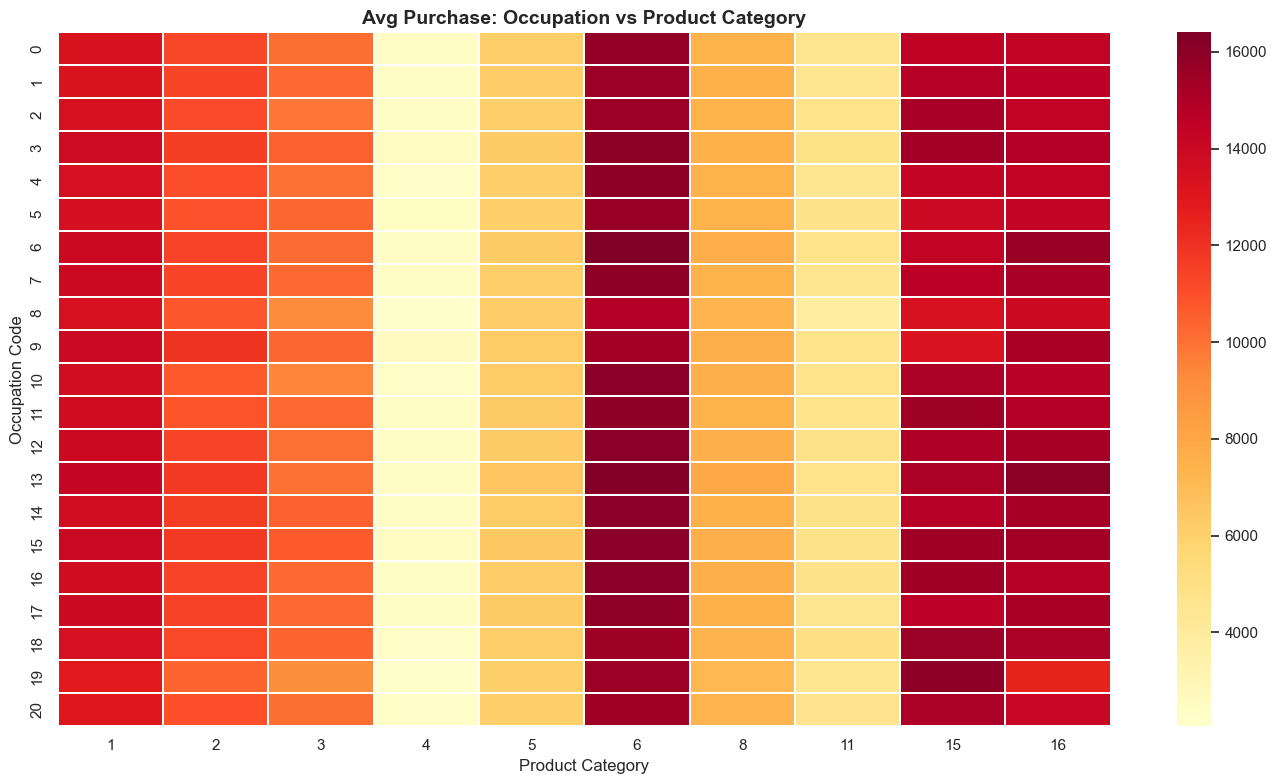

Insight 1: Certain occupations consistently spend more on specific categories — useful for personalized recommendations.
Insight 2: Product categories like 1,6,15 and 16 are being purchased significantly by all the occupations.


In [29]:
# Top 10 categories only for readability
top_cats = df_clean['Product_Category_1'].value_counts().head(10).index
df_top = df_clean[df_clean['Product_Category_1'].isin(top_cats)]

pivot = df_top.groupby(['Occupation', 'Product_Category_1'])['Purchase'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.3,cbar=True)
plt.title('Avg Purchase: Occupation vs Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Occupation Code')
plt.tight_layout()
plt.savefig('occupation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight 1: Certain occupations consistently spend more on specific categories — useful for personalized recommendations.')
print('Insight 2: Product categories like 1,6,15 and 16 are being purchased significantly by all the occupations.')

---
## 8. Multi-Column Analysis

### 8.1 Age + Gender — Who Spends Most?

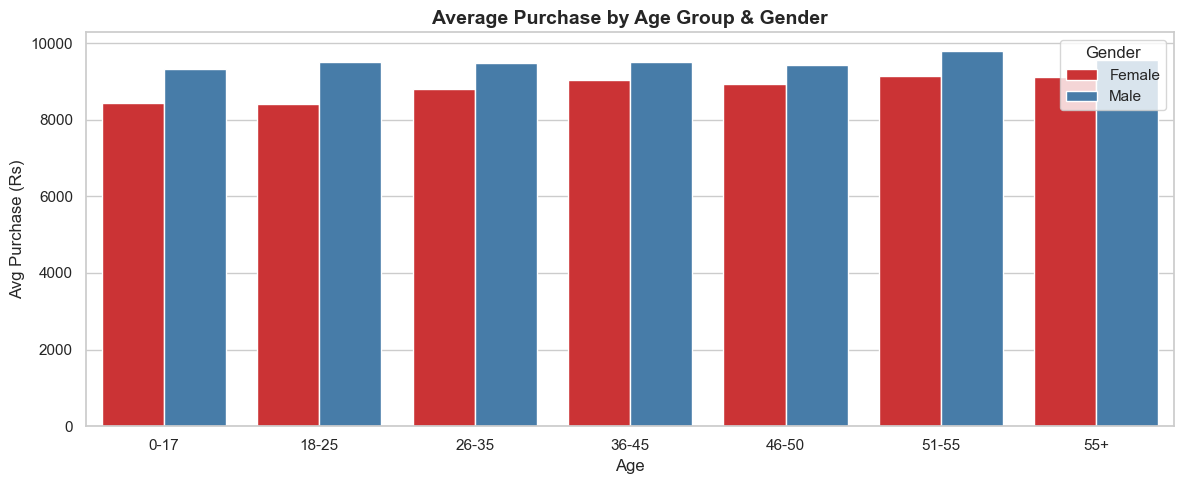

Insight: Male customers in 51-55 age group have highest average spend per transaction.


In [30]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

plt.figure(figsize=(12, 5))
age_gender = df_clean.groupby(['Age', 'Gender'])['Purchase'].mean().reset_index()
sns.barplot(data=age_gender, x='Age', y='Purchase', hue='Gender',
            order=age_order, palette='Set1')
plt.title('Average Purchase by Age Group & Gender', fontsize=14, fontweight='bold')
plt.ylabel('Avg Purchase (Rs)')
plt.tight_layout()
plt.savefig('age_gender_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Male customers in 51-55 age group have highest average spend per transaction.')

### 8.2 City + Age Group

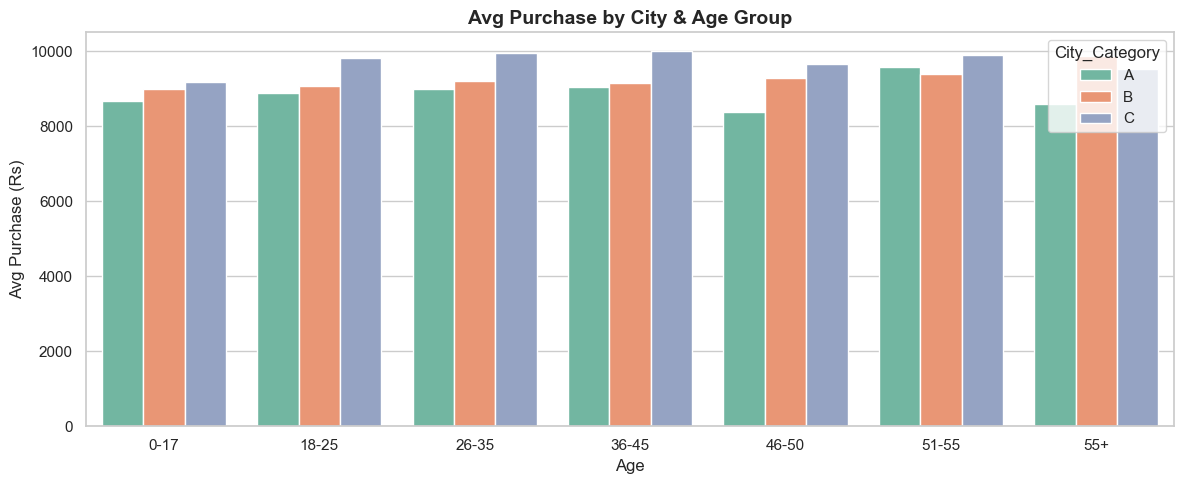

Insight: customers in 36-45 age group with city category C have highest average spend per transaction.


In [34]:
plt.figure(figsize=(12, 5))
city_age = df_clean.groupby(['City_Category', 'Age'])['Purchase'].mean().reset_index()
sns.barplot(data=city_age, x='Age', y='Purchase', hue='City_Category',
            order=age_order, palette='Set2')
plt.title('Avg Purchase by City & Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Avg Purchase (Rs)')
plt.tight_layout()
plt.savefig('city_age_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: customers in 36-45 age group with city category C have highest average spend per transaction.')

# 8. Summary Dashboard

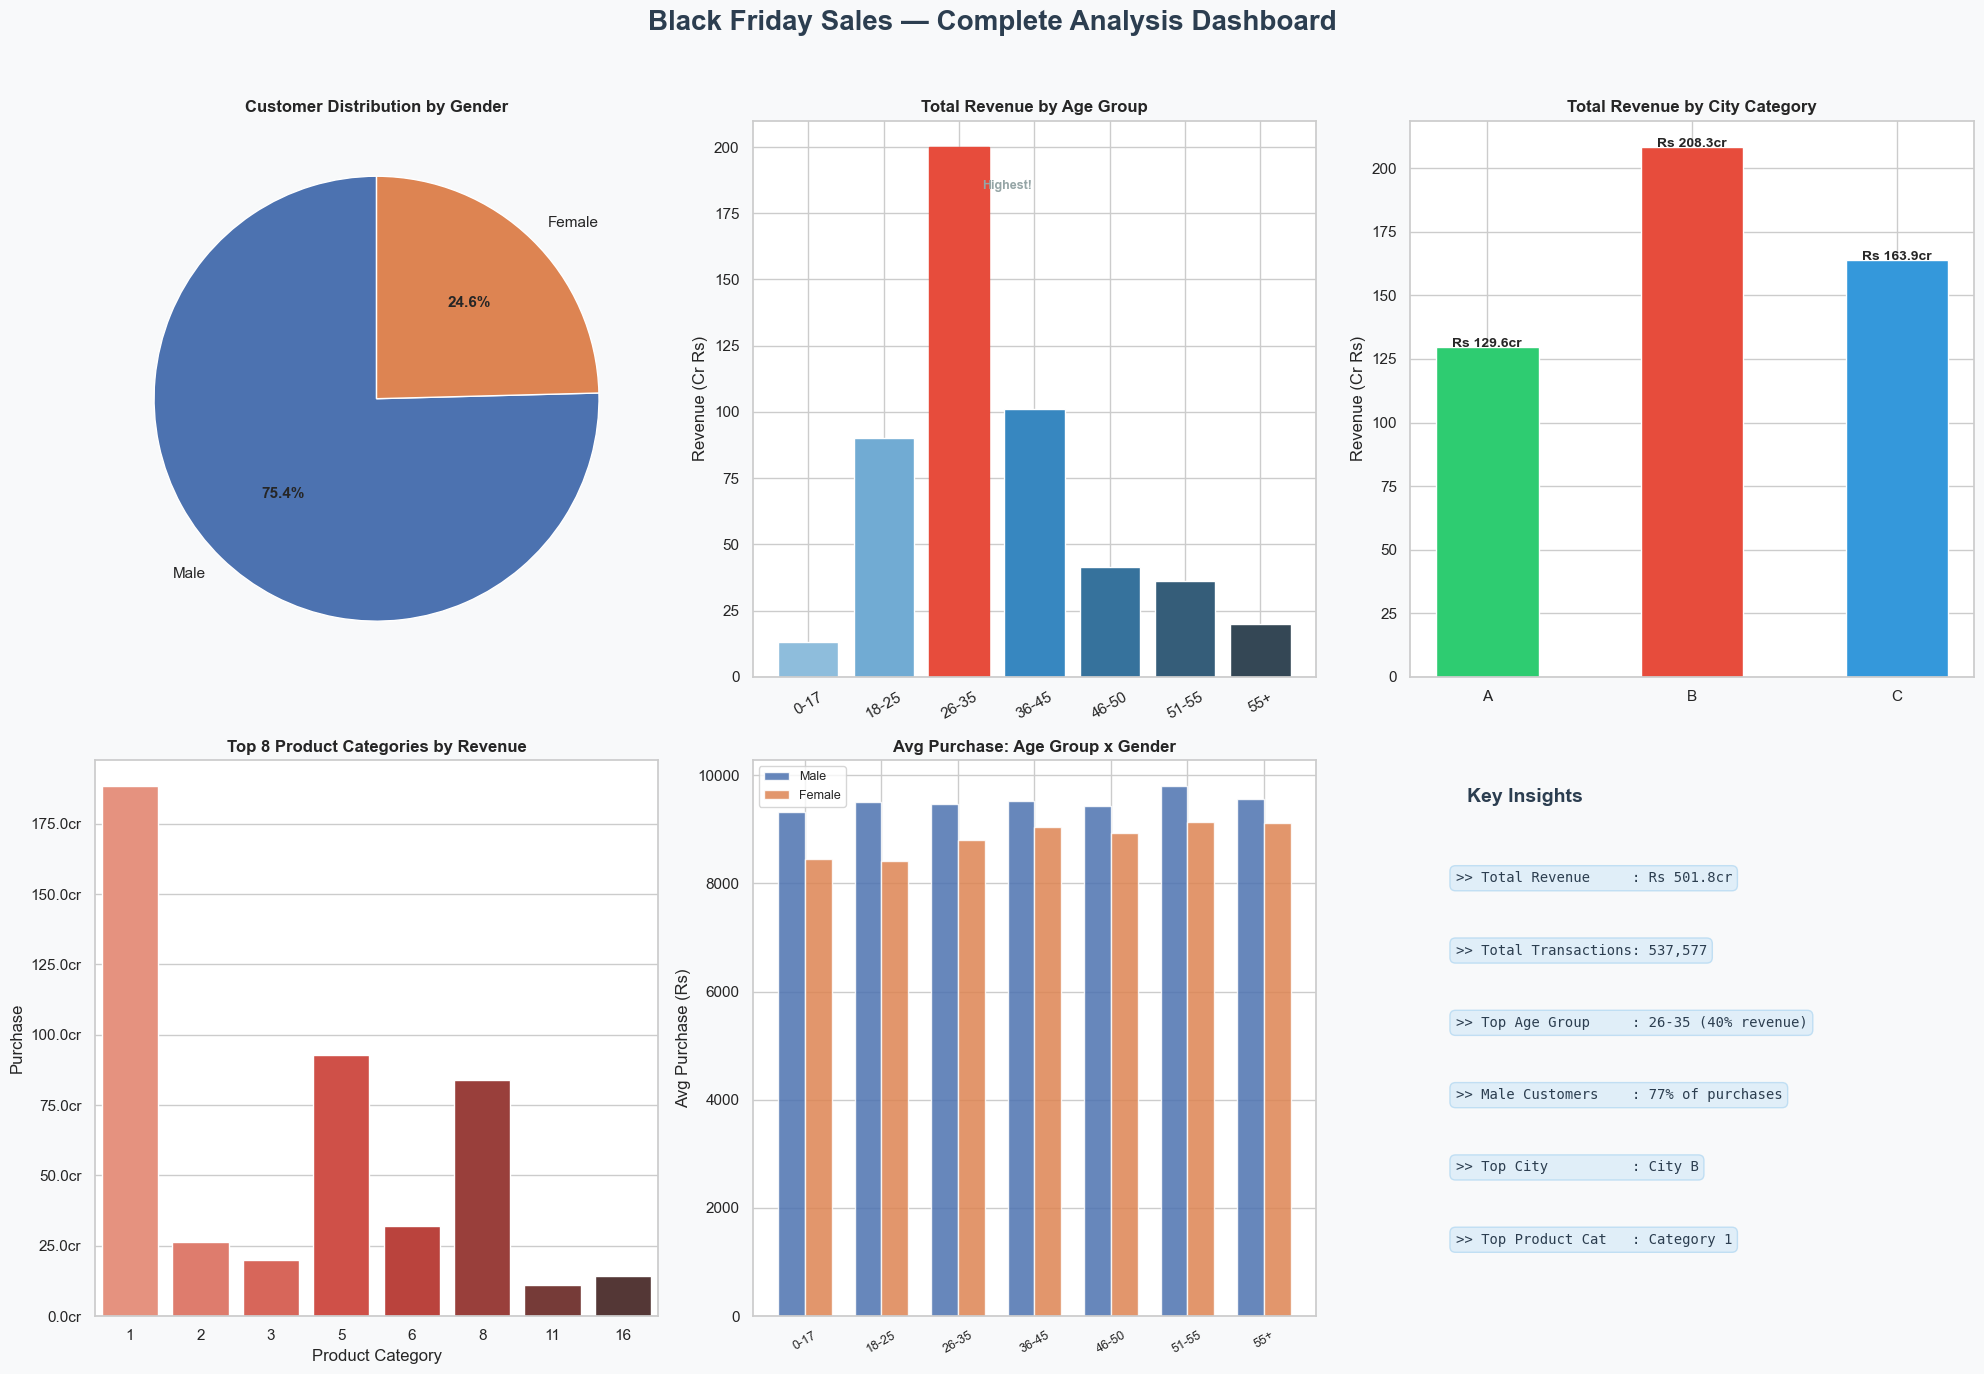

Summary dashboard saved to BlackFriday/summary_dashboard.png


In [17]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#F8F9FA')
plt.suptitle('Black Friday Sales — Complete Analysis Dashboard',
             fontsize=20, fontweight='bold', y=0.98, color='#2C3E50')

# ── Chart 1: Gender Pie (top-left) ──
ax1 = fig.add_subplot(2, 3, 1)
gender_count = df_clean['Gender'].value_counts()
wedges, texts, autotexts = ax1.pie(
    gender_count, labels=gender_count.index,
    autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
    startangle=90, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Customer Distribution by Gender', fontsize=12, fontweight='bold')

# ── Chart 2: Age Group Revenue (top-center) ──
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
ax2 = fig.add_subplot(2, 3, 2)
age_purchase = df_clean.groupby('Age')['Purchase'].sum().reindex(age_order).reset_index()
bars = ax2.bar(age_purchase['Age'], age_purchase['Purchase'] / 1e7,
               color=sns.color_palette('Blues_d', len(age_order)))
max_idx = age_purchase['Purchase'].idxmax()
bars[max_idx].set_color('#E74C3C')
ax2.annotate('Highest!',
             xy=(max_idx, age_purchase['Purchase'].max() / 1e7),
             xytext=(max_idx + 0.3, age_purchase['Purchase'].max() / 1e7 * 0.92),
             fontsize=9, color='#95A5A6', fontweight='bold')
ax2.set_title('Total Revenue by Age Group', fontsize=12, fontweight='bold')
ax2.set_ylabel('Revenue (Cr Rs)')
ax2.tick_params(axis='x', rotation=30)

# ── Chart 3: City Revenue (top-right) ──
ax3 = fig.add_subplot(2, 3, 3)
city_purchase = df_clean.groupby('City_Category')['Purchase'].sum().reset_index()
city_colors = ['#2ECC71', '#E74C3C', '#3498DB']
bars3 = ax3.bar(city_purchase['City_Category'], city_purchase['Purchase'] / 1e7,
                color=city_colors, width=0.5)
for bar, val in zip(bars3, city_purchase['Purchase'] / 1e7):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'Rs {val:.1f}cr', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Total Revenue by City Category', fontsize=12, fontweight='bold')
ax3.set_ylabel('Revenue (Cr Rs)')

# ── Chart 4: Top Product Categories (bottom-left) ──
ax4 = fig.add_subplot(2, 3, 4)
cat_revenue = df_clean.groupby('Product_Category_1')['Purchase'].sum().nlargest(8).reset_index()
sns.barplot(data=cat_revenue, x='Product_Category_1', y='Purchase', ax=ax4, palette='Reds_d')
ax4.set_title('Top 8 Product Categories by Revenue', fontsize=12, fontweight='bold')
ax4.set_xlabel('Product Category')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e7:.1f}cr'))

# ── Chart 5: Age x Gender (bottom-center) ──
ax5 = fig.add_subplot(2, 3, 5)
age_gender = df_clean.groupby(['Age', 'Gender'])['Purchase'].mean().reset_index()
male   = age_gender[age_gender['Gender'] == 'Male'].set_index('Age').reindex(age_order)
female = age_gender[age_gender['Gender'] == 'Female'].set_index('Age').reindex(age_order)
x = range(len(age_order))
width = 0.35
ax5.bar([i - width/2 for i in x], male['Purchase'],   width, label='Male',   color='#4C72B0', alpha=0.85)
ax5.bar([i + width/2 for i in x], female['Purchase'], width, label='Female', color='#DD8452', alpha=0.85)
ax5.set_xticks(list(x))
ax5.set_xticklabels(age_order, rotation=30, fontsize=9)
ax5.set_title('Avg Purchase: Age Group x Gender', fontsize=12, fontweight='bold')
ax5.set_ylabel('Avg Purchase (Rs)')
ax5.legend(fontsize=9)

# ── Chart 6: Key Insights Box (bottom-right) ──
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

top_age     = df_clean.groupby('Age')['Purchase'].sum().idxmax()
top_age_pct = df_clean.groupby('Age')['Purchase'].sum().max() / df_clean['Purchase'].sum() * 100
male_pct    = df_clean[df_clean['Gender'] == 'Male']['Purchase'].sum() / df_clean['Purchase'].sum() * 100
top_city    = df_clean.groupby('City_Category')['Purchase'].sum().idxmax()
top_cat     = df_clean.groupby('Product_Category_1')['Purchase'].sum().idxmax()
total_rev   = df_clean['Purchase'].sum() / 1e7

insights = [
    f'Total Revenue     : Rs {total_rev:.1f}cr',
    f'Total Transactions: {len(df_clean):,}',
    f'Top Age Group     : {top_age} ({top_age_pct:.0f}% revenue)',
    f'Male Customers    : {male_pct:.0f}% of purchases',
    f'Top City          : City {top_city}',
    f'Top Product Cat   : Category {top_cat}',
]

ax6.text(0.1, 0.95, 'Key Insights', transform=ax6.transAxes,
         fontsize=14, fontweight='bold', color='#2C3E50', va='top')

for i, insight in enumerate(insights):
    ax6.text(0.08, 0.80 - i * 0.13, f'>> {insight}', transform=ax6.transAxes,
             fontsize=10, color='#2C3E50', va='top', family='monospace',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#D6EAF8',
                       alpha=0.7, edgecolor='#AED6F1'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('summary_dashboard.png', dpi=180, bbox_inches='tight')
facecolor=fig.get_facecolor()
plt.show()
print('Summary dashboard saved to BlackFriday/summary_dashboard.png')

---
## 9. Key Business Insights Summary

In [35]:
print('=' * 60)
print('KEY INSIGHTS — BLACK FRIDAY SALES ANALYSIS')
print('=' * 60)

# 1. Top age group
top_age = df_clean.groupby('Age')['Purchase'].sum().idxmax()
top_age_pct = df_clean.groupby('Age')['Purchase'].sum().max() / df_clean['Purchase'].sum() * 100
print(f'1. Age group {top_age} contributes {top_age_pct:.1f}% of total revenue')

# 2. Gender
male_pct = df_clean[df_clean['Gender'] == 'Male']['Purchase'].sum() / df_clean['Purchase'].sum() * 100
print(f'2. Male customers drive {male_pct:.1f}% of total purchases')

# 3. Top city
top_city = df_clean.groupby('City_Category')['Purchase'].sum().idxmax()
print(f'3. City {top_city} generates highest total revenue')

# 4. Top product category
top_cat = df_clean.groupby('Product_Category_1')['Purchase'].sum().idxmax()
print(f'4. Product Category {top_cat} has highest total revenue')

# 5. Single vs married
single_avg = df_clean[df_clean['Marital_Status'] == 'Single']['Purchase'].mean()
married_avg = df_clean[df_clean['Marital_Status'] == 'Married']['Purchase'].mean()
print(f'5. Single customers avg spend: Rs {single_avg:.0f} | Married: Rs {married_avg:.0f}')

print('=' * 60)

KEY INSIGHTS — BLACK FRIDAY SALES ANALYSIS
1. Age group 26-35 contributes 39.9% of total revenue
2. Male customers drive 76.8% of total purchases
3. City B generates highest total revenue
4. Product Category 1 has highest total revenue
5. Single customers avg spend: Rs 9333 | Married: Rs 9335
